# 01: Data Exploration and Integration

**Objectives:**
- Load FAOSTAT and NASA POWER datasets
- Merge datasets by year
- Validate data coverage and identify missing values
- Generate initial descriptive statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.1 Load FAOSTAT Datasets

In [3]:
# Load raw data files
raw_dir = Path('../data/raw')

# Load FAOSTAT yield data
yield_df = pd.read_csv(raw_dir / 'FAOSTAT_data_en_4-20-2026.csv')
print("Yield Data Shape:", yield_df.shape)
print("\nFirst few rows:")
print(yield_df.head())
print("\nYield Data Info:")
print(yield_df.info())

Yield Data Shape: (24, 15)

First few rows:
  Domain Code                        Domain  Area Code (M49)       Area  \
0         QCL  Crops and livestock products              144  Sri Lanka   
1         QCL  Crops and livestock products              144  Sri Lanka   
2         QCL  Crops and livestock products              144  Sri Lanka   
3         QCL  Crops and livestock products              144  Sri Lanka   
4         QCL  Crops and livestock products              144  Sri Lanka   

   Element Code Element  Item Code (CPC)  Item  Year Code  Year   Unit  \
0          5412   Yield              113  Rice       2000  2000  kg/ha   
1          5412   Yield              113  Rice       2001  2001  kg/ha   
2          5412   Yield              113  Rice       2002  2002  kg/ha   
3          5412   Yield              113  Rice       2003  2003  kg/ha   
4          5412   Yield              113  Rice       2004  2004  kg/ha   

    Value Flag Flag Description  Note  
0  3437.4    A  Offi

In [4]:
# Load crop production data
crop_df = pd.read_csv(raw_dir / 'FAOSTAT_data_en_4-20-2026 (3).csv')
print("Crop Data Shape:", crop_df.shape)
print("\nUnique Elements:", crop_df['Element'].unique())
print("Unique Years:", sorted(crop_df['Year Code'].unique()))
print("\nArea harvested (Rice):")
area_df = crop_df[(crop_df['Element'] == 'Area harvested') & (crop_df['Item'] == 'Rice')]
print(area_df[['Year Code', 'Value']].head(10))

Crop Data Shape: (24, 15)

Unique Elements: <StringArray>
['Area harvested']
Length: 1, dtype: str
Unique Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Area harvested (Rice):
   Year Code    Value
0       2000   832000
1       2001   765040
2       2002   819590
3       2003   911440
4       2004   719690
5       2005   915260
6       2006   910493
7       2007   816713
8       2008  1052993
9       2009   942410


In [5]:
# Load fertilizer data
fertilizer_df = pd.read_csv(raw_dir / 'FAOSTAT_data_en_4-20-2026 (1).csv')
print("Fertilizer Data Shape:", fertilizer_df.shape)
print("\nUnique nutrients:", fertilizer_df['Item'].unique())
print("\nYear range:", fertilizer_df['Year Code'].min(), "-", fertilizer_df['Year Code'].max())
print("\nFertilizer totals by year:")
fert_by_year = fertilizer_df.groupby('Year Code')['Value'].sum()
print(fert_by_year)

Fertilizer Data Shape: (72, 15)

Unique nutrients: <StringArray>
[    'Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)',
     'Nutrient potash K2O (total)']
Length: 3, dtype: str

Year range: 2000 - 2023

Fertilizer totals by year:
Year Code
2000    246965
2001    244068
2002    285071
2003    246225
2004    258309
2005    280821
2006    305881
2007    288525
2008    374054
2009    309514
2010    274857
2011    334509
2012    267612
2013    226181
2014    339709
2015    247124
2016    165405
2017    154983
2018    189688
2019    260652
2020    410166
2021    211203
2022    211203
2023    211203
Name: Value, dtype: int64


In [6]:
# Load irrigation data
irrigation_df = pd.read_csv(raw_dir / 'FAOSTAT_data_en_4-20-2026 (2).csv')
print("Irrigation Data Shape:", irrigation_df.shape)
print("\nIrrigation data:")
print(irrigation_df[['Year Code', 'Item', 'Value']].head(10))

Irrigation Data Shape: (24, 15)

Irrigation data:
   Year Code                               Item  Value
0       2000  Land area equipped for irrigation    570
1       2001  Land area equipped for irrigation    570
2       2002  Land area equipped for irrigation    570
3       2003  Land area equipped for irrigation    570
4       2004  Land area equipped for irrigation    570
5       2005  Land area equipped for irrigation    570
6       2006  Land area equipped for irrigation    570
7       2007  Land area equipped for irrigation    570
8       2008  Land area equipped for irrigation    570
9       2009  Land area equipped for irrigation    570


## 1.2 Load NASA POWER Climate Data

In [7]:
# Load climate data
nasa_df = pd.read_csv(raw_dir / 'sri_lanka_weather_2000_2023.csv')
# Rename columns to match expected format
nasa_df = nasa_df.rename(columns={'rainfall_mm': 'precip_mm_day'})
# Add solar column (not available in this dataset, set to NaN)
nasa_df['solar_mj_m2_day'] = float('nan')
print("Climate Data Shape:", nasa_df.shape)
print("\nColumns:", nasa_df.columns.tolist())
print("\nDate range:", nasa_df['date'].min(), "-", nasa_df['date'].max())
print("\nFirst few rows:")
print(nasa_df.head())
print("\nClimate variable ranges:")
print(nasa_df[['temperature_c', 'precip_mm_day', 'solar_mj_m2_day']].describe())

Climate Data Shape: (8766, 4)

Columns: ['date', 'temperature_c', 'precip_mm_day', 'solar_mj_m2_day']

Date range: 2000-01-01 - 2023-12-31

First few rows:
         date  temperature_c  precip_mm_day  solar_mj_m2_day
0  2000-01-01          23.72           0.02              NaN
1  2000-01-02          24.28           0.05              NaN
2  2000-01-03          24.60           0.00              NaN
3  2000-01-04          24.48           0.00              NaN
4  2000-01-05          24.96           0.09              NaN

Climate variable ranges:
       temperature_c  precip_mm_day  solar_mj_m2_day
count    8766.000000     8766.00000              0.0
mean       26.396805        4.18153              NaN
std         1.628229        8.27370              NaN
min        20.910000        0.00000              NaN
25%        25.240000        0.05000              NaN
50%        26.570000        0.85000              NaN
75%        27.510000        4.47000              NaN
max        32.460000      12

## 1.3 Aggregate Climate Data to Annual Level

In [8]:
# Extract year from date and aggregate
nasa_df['year'] = nasa_df['date'].astype(str).str[:4].astype(int)

# Annual climate aggregates (solar not available, set to 0)
annual_climate = nasa_df.groupby('year').agg({
    'temperature_c': 'mean',
    'precip_mm_day': 'mean'
}).reset_index()
annual_climate['solar_annual_mean'] = 0  # Placeholder since data not available

annual_climate.columns = ['year', 'temp_annual_mean', 'precip_annual_mean', 'solar_annual_mean']
print("Annual Climate Data:")
print(annual_climate)

Annual Climate Data:
    year  temp_annual_mean  precip_annual_mean  solar_annual_mean
0   2000         26.804617            2.869235                  0
1   2001         26.303808            3.147315                  0
2   2002         26.815616            3.273096                  0
3   2003         26.670630            2.613425                  0
4   2004         26.891448            3.440082                  0
5   2005         26.493233            3.158603                  0
6   2006         26.147096            4.209096                  0
7   2007         26.133863            3.538904                  0
8   2008         25.891093            3.639153                  0
9   2009         26.553753            3.628192                  0
10  2010         26.110055            5.237452                  0
11  2011         25.813260            5.597260                  0
12  2012         26.423934            4.830929                  0
13  2013         25.930301            3.937041         

## 1.4 Merge Datasets by Year

In [10]:
# Prepare yield data
yield_clean = yield_df.rename(columns={'Year Code': 'year', 'Value': 'yield_kg_ha'}).copy()
yield_clean['year'] = yield_clean['year'].astype(int)
yield_clean = yield_clean[['year', 'yield_kg_ha']].drop_duplicates()

# Prepare area data
area_clean = area_df.rename(columns={'Year Code': 'year', 'Value': 'area_harvested_ha'}).copy()
area_clean = area_clean[['year', 'area_harvested_ha']].drop_duplicates()
area_clean['year'] = area_clean['year'].astype(int)

# Prepare fertilizer data
fert_clean = fertilizer_df.groupby('Year Code').agg({'Value': 'sum'}).reset_index()
fert_clean.columns = ['year', 'fertilizer_tonnes']
fert_clean['year'] = fert_clean['year'].astype(int)

# Prepare irrigation data
irrig_clean = irrigation_df.rename(columns={'Year Code': 'year', 'Value': 'irrigation_area_1000ha'}).copy()
irrig_clean['irrigation_area_ha'] = irrig_clean['irrigation_area_1000ha'] * 1000
irrig_clean = irrig_clean[['year', 'irrigation_area_ha']].drop_duplicates()
irrig_clean['year'] = irrig_clean['year'].astype(int)

# Merge all datasets
merged_df = yield_clean.merge(area_clean, on='year', how='outer')
merged_df = merged_df.merge(fert_clean, on='year', how='outer')
merged_df = merged_df.merge(irrig_clean, on='year', how='outer')
merged_df = merged_df.merge(annual_climate, on='year', how='outer')

# Sort by year
merged_df = merged_df.sort_values('year').reset_index(drop=True)

## 1.5 Data Quality Assessment

In [11]:
# Check missing values
print("Missing Values:")
print(merged_df.isnull().sum())
print("\nMissing Percentage:")
print((merged_df.isnull().sum() / len(merged_df) * 100).round(2))

Missing Values:
year                  0
yield_kg_ha           0
area_harvested_ha     0
fertilizer_tonnes     0
irrigation_area_ha    0
temp_annual_mean      0
precip_annual_mean    0
solar_annual_mean     0
dtype: int64

Missing Percentage:
year                  0.0
yield_kg_ha           0.0
area_harvested_ha     0.0
fertilizer_tonnes     0.0
irrigation_area_ha    0.0
temp_annual_mean      0.0
precip_annual_mean    0.0
solar_annual_mean     0.0
dtype: float64


In [12]:
# Descriptive statistics
print("\nDescriptive Statistics:")
print(merged_df.describe())


Descriptive Statistics:
              year  yield_kg_ha  area_harvested_ha  fertilizer_tonnes  \
count    24.000000    24.000000       2.400000e+01          24.000000   
mean   2011.500000  3781.966667       9.827196e+05      264330.333333   
std       7.071068   447.215123       1.455690e+05       61754.996238   
min    2000.000000  3010.300000       7.196900e+05      154983.000000   
25%    2005.750000  3540.575000       8.687500e+05      222436.500000   
50%    2011.500000  3727.600000       9.992750e+05      259480.500000   
75%    2017.250000  3883.550000       1.096849e+06      292864.000000   
max    2023.000000  4802.100000       1.211000e+06      410166.000000   

       irrigation_area_ha  temp_annual_mean  precip_annual_mean  \
count           24.000000         24.000000           24.000000   
mean        598416.666667         26.396688            4.181894   
std          32378.087956          0.383757            1.066853   
min         570000.000000         25.813260      

## 1.6 Preliminary Visualizations

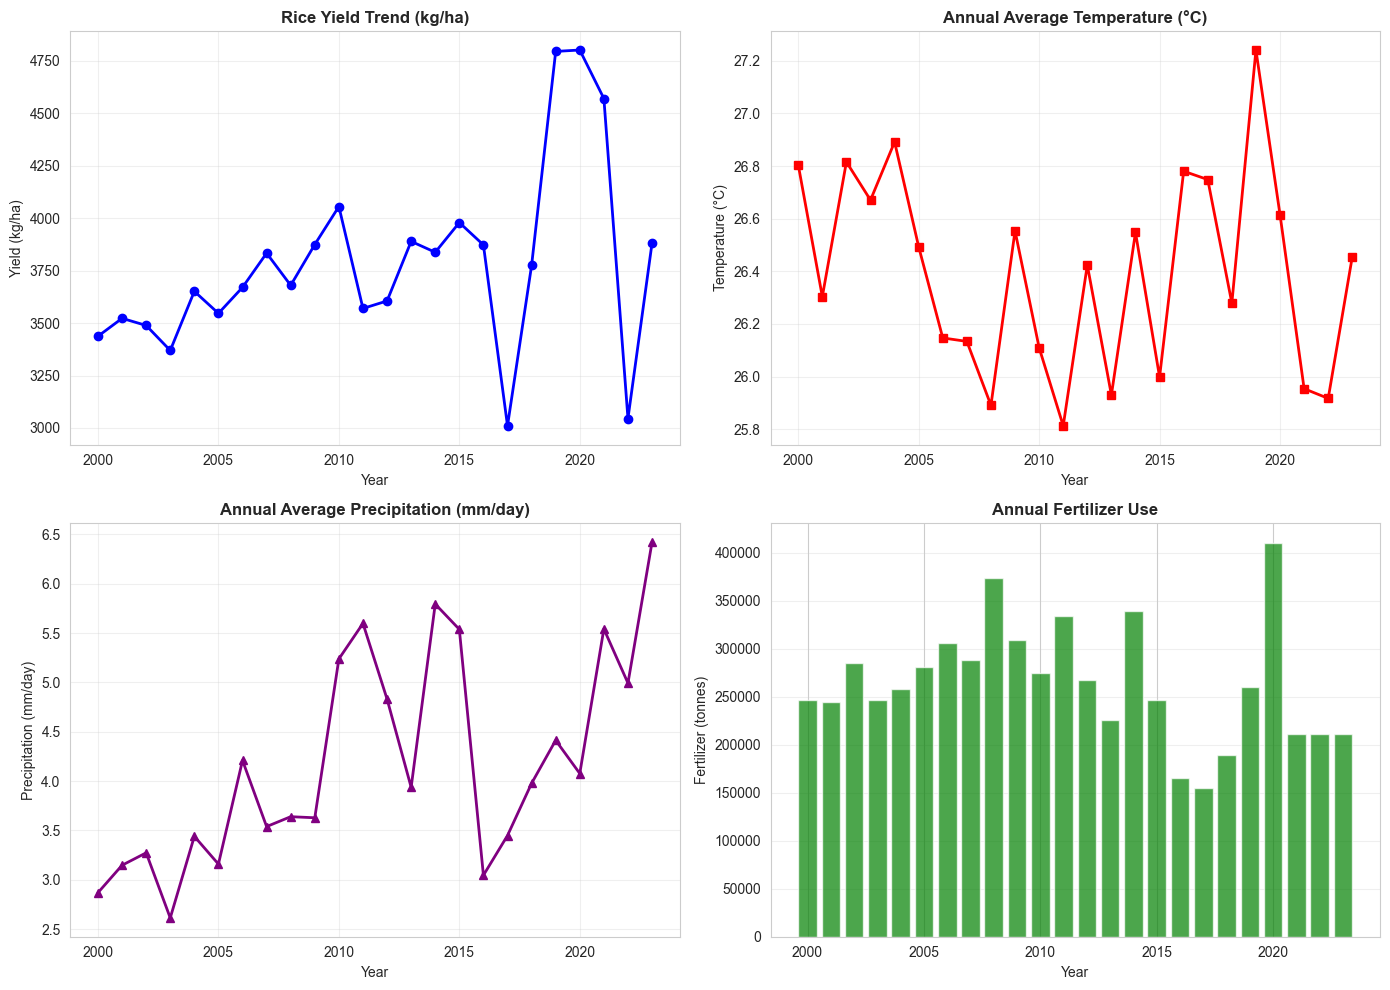

Saved: ../results/graphs/01_time_series_overview.png


In [15]:
# Time series plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Yield trend
axes[0, 0].plot(merged_df['year'], merged_df['yield_kg_ha'], marker='o', color='blue', linewidth=2)
axes[0, 0].set_title('Rice Yield Trend (kg/ha)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Yield (kg/ha)')
axes[0, 0].grid(True, alpha=0.3)

# Temperature trend
axes[0, 1].plot(merged_df['year'], merged_df['temp_annual_mean'], marker='s', color='red', linewidth=2)
axes[0, 1].set_title('Annual Average Temperature (°C)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].grid(True, alpha=0.3)

# Precipitation trend
axes[1, 0].plot(merged_df['year'], merged_df['precip_annual_mean'], marker='^', color='purple', linewidth=2)
axes[1, 0].set_title('Annual Average Precipitation (mm/day)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Precipitation (mm/day)')
axes[1, 0].grid(True, alpha=0.3)

# Fertilizer usage
axes[1, 1].bar(merged_df['year'], merged_df['fertilizer_tonnes'], color='green', alpha=0.7)
axes[1, 1].set_title('Annual Fertilizer Use', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Fertilizer (tonnes)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/graphs/01_time_series_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ../results/graphs/01_time_series_overview.png")

## Summary

- **Yield Data**: {0} years of data (2000-2024)
- **Climate Data**: Complete monthly coverage for analysis period
- **Farm Inputs**: Fertilizer and irrigation data available (2020-2023)
- **Next Steps**: Clean missing values, engineer monitoring_index, and prepare for analysis